In [1]:
import scanpy as sc

adata = sc.read_h5ad(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad")

adata

AnnData object with n_obs × n_vars = 77668 × 33539
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pmito', 'n_genes', 'Condition', 'louvain', 'scv2+', 'louvain_res0.5', 'ctype_res0.5', 'ctype', 'subctype', 'init_ctype', 'scv2_5+', 'scv2_10+', 'raw', 'res_inf', 'ees_inf', 'Group', 'dpi', 'inf_scv2_5+', 'inf_scv2_10+', 'Viral_transcript'

In [ ]:
# 去除所有的mock cell，因為文獻沒有定義清楚

adata = adata[adata.obs["Condition"] != "Mock"].copy()

In [3]:
adata.obs["Condition"].unique()

['1dpi', <NA>, '2dpi', '3dpi']
Categories (3, string): [1dpi, 2dpi, 3dpi]

In [4]:
# 整體品質管控
adata_qc = adata[
    (adata.obs["pmito"] < 0.2) # 粒線體的的RNA比例超過0.2，代表細胞品質不好
    &
    (adata.obs["n_genes"] > 500) # 基因表達數量需要高於500(根據分布，已屬於寬鬆的結果)，較具有特徵
].copy()

# 去除幾乎沒有表達的基因
sc.pp.filter_genes(
    adata_qc,
    min_cells=10
)

# 特徵選取(HVG)
sc.pp.highly_variable_genes(
    adata_qc,
    flavor="seurat_v3",
    n_top_genes=3000
)

adata_qc = adata_qc[
    :,
    adata_qc.var["highly_variable"]
].copy()

# normalization
sc.pp.normalize_total(
    adata_qc,
    target_sum=1e4
)

sc.pp.log1p(
    adata_qc
)

In [5]:
# 看一下若有偵測到病毒轉錄體的情況下，病毒轉錄體的分布，以決定感染標籤的標準
print("偵測到病毒轉錄體的情況下，病毒轉錄體的分布:")
print(adata_qc.obs[adata_qc.obs["Viral_transcript"] > 0]["Viral_transcript"].describe())

# 偵測到病毒轉錄體的情況下，病毒轉錄體的分布:
# count    38142.000000
# mean        87.999895
# std        599.095697
# min          1.000000
# 25%          1.000000
# 50%          3.000000
# 75%          4.000000
# max      18682.000000

# 由資料分布決定 virus threshold
virus_threshold = (
    adata_qc.obs.loc[
        adata_qc.obs["Viral_transcript"] > 0, # 未偵測到病毒轉錄體的細胞不考慮
        "Viral_transcript"
    ]
    .quantile(0.95)
)

positive_cell = adata_qc[
    (adata_qc.obs["Viral_transcript"] >= virus_threshold)
    &
    (adata_qc.obs["n_genes"] > 1000) # 高可信標籤需要更嚴格的標準(避免Empty droplet)
]

# 選取未感染的細胞
negative_cell = adata_qc[
    (adata_qc.obs["Viral_transcript"] == 0) # 沒有偵測到病毒轉錄體
    &
    (adata_qc.obs["n_genes"] > 1000) # 高可信標籤需要更嚴格的標準(避免Empty droplet)
    &
    (adata_qc.obs["Condition"] == "1dpi") # 確定未感染的細胞
]


偵測到病毒轉錄體的情況下，病毒轉錄體的分布:
count    38142.000000
mean        87.999895
std        599.095697
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max      18682.000000
Name: Viral_transcript, dtype: float64


In [6]:
# 確認高可信度細胞的資料品質
print("高可信度細胞的資料品質:")
print("positive")
print(positive_cell.obs[
    ["Viral_transcript", "n_genes", "pmito"]
].describe())
print("")
print("negative")
print(negative_cell.obs[
    ["Viral_transcript", "n_genes", "pmito"]
].describe())

# 高可信度細胞的資料品質:
# positive
#        Viral_transcript      n_genes        pmito
# count       1707.000000  1707.000000  1707.000000
# mean        1699.687170  3825.326889     0.070002
# std         2218.465566  1769.385352     0.031635
# min          166.000000  1009.000000     0.001452
# 25%          428.500000  2328.500000     0.049535
# 50%          875.000000  3655.000000     0.069449
# 75%         2014.000000  5103.000000     0.088632
# max        18682.000000  9009.000000     0.196126

# negative
#        Viral_transcript       n_genes        pmito
# count            7505.0   7505.000000  7505.000000
# mean                0.0   4115.884077     0.071221
# std                 0.0   1694.333358     0.031392
# min                 0.0   1001.000000     0.000286
# 25%                 0.0   2976.000000     0.051354
# 50%                 0.0   3918.000000     0.068468
# 75%                 0.0   5083.000000     0.087912
# max                 0.0  10571.000000     0.198859

高可信度細胞的資料品質:
positive
       Viral_transcript      n_genes        pmito
count       1707.000000  1707.000000  1707.000000
mean        1699.687170  3825.326889     0.070002
std         2218.465566  1769.385352     0.031635
min          166.000000  1009.000000     0.001452
25%          428.500000  2328.500000     0.049535
50%          875.000000  3655.000000     0.069449
75%         2014.000000  5103.000000     0.088632
max        18682.000000  9009.000000     0.196126

negative
       Viral_transcript       n_genes        pmito
count            7505.0   7505.000000  7505.000000
mean                0.0   4115.884077     0.071221
std                 0.0   1694.333358     0.031392
min                 0.0   1001.000000     0.000286
25%                 0.0   2976.000000     0.051354
50%                 0.0   3918.000000     0.068468
75%                 0.0   5083.000000     0.087912
max                 0.0  10571.000000     0.198859


In [7]:
# 取得已標籤 cell 的 index
positive_idx = positive_cell.obs_names
negative_idx = negative_cell.obs_names

# unknown = QC後資料扣掉positive和negative
unknown_cell = adata_qc[
    ~adata_qc.obs_names.isin(positive_idx.union(negative_idx))
]

In [ ]:
# 檢查不確定細胞的資料品質
print("未知狀態細胞的資料品質:")
print(unknown_cell.obs[
    ["Viral_transcript", "n_genes", "pmito"]
].describe())

# 未知狀態細胞的資料品質:
#        Viral_transcript       n_genes         pmito
# count      42769.000000  42769.000000  42769.000000
# mean          10.641493   2946.132526      0.081955
# std          123.497659   1604.928279      0.029685
# min            0.000000    501.000000      0.000662
# 25%            1.000000   1705.000000      0.062525
# 50%            2.000000   2654.000000      0.080265
# 75%            4.000000   3822.000000      0.099287
# max         8650.000000  10136.000000      0.199936

未知狀態細胞的資料品質:
       Viral_transcript       n_genes         pmito
count      42769.000000  42769.000000  42769.000000
mean          10.641493   2946.132526      0.081955
std          123.497659   1604.928279      0.029685
min            0.000000    501.000000      0.000662
25%            1.000000   1705.000000      0.062525
50%            2.000000   2654.000000      0.080265
75%            4.000000   3822.000000      0.099287
max         8650.000000  10136.000000      0.199936


In [9]:
# 在資料中新增標籤欄位
# 初始化 unknown
adata_qc.obs["label"] = -1


# infected
adata_qc.obs.loc[
    positive_cell.obs_names,
    "label"
] = 1


# uninfected
adata_qc.obs.loc[
    negative_cell.obs_names,
    "label"
] = 0

adata_qc.obs["label_source"] = "unknown"

adata_qc.obs.loc[
    positive_cell.obs_names,
    "label_source"
] = "high_confidence_infected"

adata_qc.obs.loc[
    negative_cell.obs_names,
    "label_source"
] = "high_confidence_uninfected"

In [ ]:
import pandas as pd

print("看一下不同細胞類型的感染狀態分布:")
print(pd.crosstab(
    adata_qc.obs["ctype"],
    adata_qc.obs["label"]
))

# 看一下不同細胞類型的感染狀態分布:
# label                    -1     0     1
# ctype                                  
# BC/Club                2036   314   124
# Basal cells           17960  1357   167
# Ciliated cells        11954  3212  1219
# Club cells             9858  2443   193
# Goblet cells             64    10     0
# Ionocytes               454    76     2
# Neuroendocrine cells    227    72     2
# Tuft cells              216    21     0

看一下不同細胞類型的感染狀態分布:
label                    -1     0     1
ctype                                  
BC/Club                2036   314   124
Basal cells           17960  1357   167
Ciliated cells        11954  3212  1219
Club cells             9858  2443   193
Goblet cells             64    10     0
Ionocytes               454    76     2
Neuroendocrine cells    227    72     2
Tuft cells              216    21     0


In [11]:
from scipy.stats import chi2_contingency

# 只留下有標籤的細胞
df = adata_qc.obs[
    adata_qc.obs["label"].isin([0, 1])
]

# 建立列聯表
table = pd.crosstab(
    df["ctype"],
    df["label"]
)


# 卡方檢定
chi2, p, dof, expected = chi2_contingency(table)

print("不考慮unknown(-1的情況下，列連表與卡方檢定結果如下:")
print(table)
print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"P-value = {p:.5e}")
print("**細胞類型與感染狀態顯著相關**")

不考慮unknown(-1的情況下，列連表與卡方檢定結果如下:
label                    0     1
ctype                           
BC/Club                314   124
Basal cells           1357   167
Ciliated cells        3212  1219
Club cells            2443   193
Goblet cells            10     0
Ionocytes               76     2
Neuroendocrine cells    72     2
Tuft cells              21     0
Chi-square = 574.217
df = 7
P-value = 8.66456e-120
**細胞類型與感染狀態顯著相關**


In [12]:
# 做PCA以建立KNN
sc.pp.scale(
    adata_qc,
    max_value=10 # 先標準化
)

sc.tl.pca(
    adata_qc,
    n_comps=50,
    svd_solver="arpack"
)

# 建立KNN
sc.pp.neighbors(
    adata_qc,
    n_neighbors=15, # 每個細胞15個鄰居
    n_pcs=50
)

print(adata_qc.obsp.keys())

c:\Users\USER\miniconda3\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


KeysView(PairwiseArrays with keys: distances, connectivities)


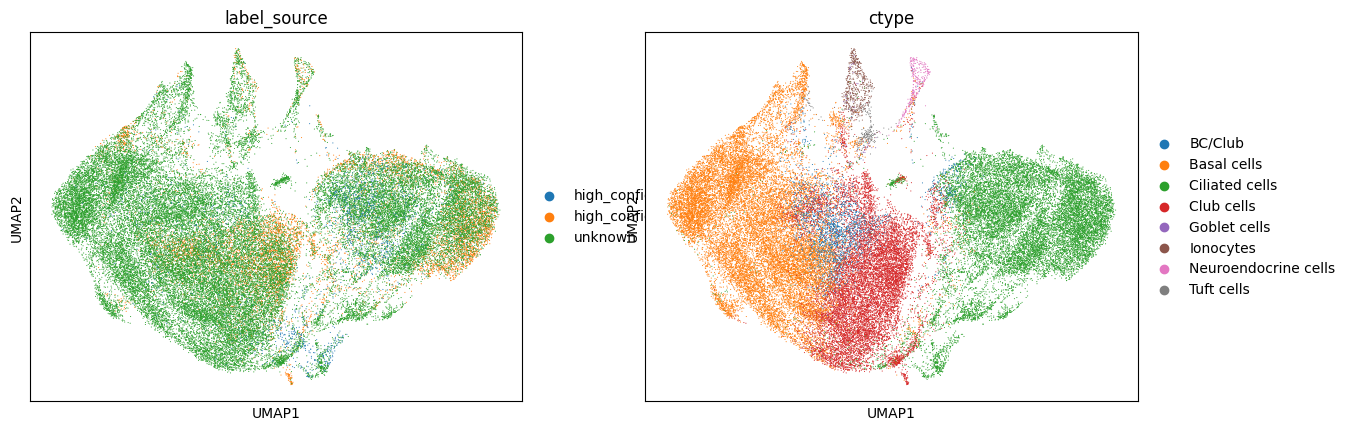

In [13]:
# 用UMAP針對不同細胞型態跟感染狀態看分群結果
sc.tl.umap(adata_qc)

sc.pl.umap(
    adata_qc,
    color=["label_source", "ctype"]
)

In [14]:
import numpy as np

X = adata_qc.X.astype(np.float32)

# 匯出細胞的節點特徵(3000個HVG)
np.save(
    "GCN_features.npy",
    X
)

In [15]:
# 匯出特徵的基因名稱
adata_qc.var_names.to_series().to_csv(
    "GCN_genes.csv",
    index=False
)

In [16]:
# 匯出label
adata_qc.obs[
    "label"
].to_csv(
    "GCN_labels.csv"
)

In [17]:
# 匯出 cell metadata
metadata_cols = [
    "ctype",
    "Condition",
    "Viral_transcript",
    "label",
    "label_source"
]

adata_qc.obs[
    metadata_cols
].to_csv(
    "GCN_metadata.csv"
)

In [19]:
# 匯出 KNN graph
from scipy import sparse

sparse.save_npz(
    "GCN_adjacency.npz",
    adata_qc.obsp["connectivities"]
)